<a href="https://colab.research.google.com/github/Kriti0906/TAHNET-Triple-Attention-Hybrid-Network-for-Traffic-Sign-Recognition/blob/main/TAHNET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('Drive mounted!')

Mounted at /content/drive
Drive mounted!


In [ ]:
%%javascript
// CELL 2 — Anti Sleep Code
function ClickConnect(){
    console.log('Keeping Colab alive...');
    document.querySelector('colab-toolbar-button#connect').click()
}
setInterval(ClickConnect, 60000)

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# CELL 3 — All Imports
# ============================================================
import os, csv, time, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, random_split
from torchvision import transforms
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print('All imports done!')

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB
All imports done!


In [ ]:
# ============================================================
# CELL 4 — Copy Dataset to Local
# ============================================================
DRIVE_GTSRB = '/content/drive/MyDrive/GTSRB'
LOCAL_GTSRB = '/content/GTSRB'

def copy_folder(src, dst):
    if os.path.exists(dst):
        print(f'{dst} already exists!')
        return
    print(f'Copying {os.path.basename(src)}...')
    shutil.copytree(src, dst)
    print(f'{os.path.basename(src)} done!')

os.makedirs(LOCAL_GTSRB, exist_ok=True)
start = time.time()

copy_folder(os.path.join(DRIVE_GTSRB, 'Train'),
            os.path.join(LOCAL_GTSRB, 'Train'))
copy_folder(os.path.join(DRIVE_GTSRB, 'Test'),
            os.path.join(LOCAL_GTSRB, 'Test'))

for f in ['Test.csv', 'Train.csv']:
    dst = os.path.join(LOCAL_GTSRB, f)
    if not os.path.exists(dst):
        shutil.copy(os.path.join(DRIVE_GTSRB, f), dst)

elapsed = (time.time() - start) / 60
print(f'\nTotal time: {elapsed:.1f} mins')
print('Contents:', os.listdir(LOCAL_GTSRB))
print(f'Train images: {sum(len(os.listdir(os.path.join(LOCAL_GTSRB,"Train",c))) for c in os.listdir(os.path.join(LOCAL_GTSRB,"Train")) if os.path.isdir(os.path.join(LOCAL_GTSRB,"Train",c)))}')
print(f'Test images:  {len(os.listdir(os.path.join(LOCAL_GTSRB,"Test")))}')
print('Dataset ready locally!')

/content/GTSRB/Train already exists!
/content/GTSRB/Test already exists!

Total time: 0.0 mins
Contents: ['Train', 'Test', 'Test.csv', 'Train.csv']
Train images: 39250
Test images:  12631
Dataset ready locally!


In [ ]:
# ============================================================
# CELL 5 — Configuration
# ============================================================
IMG_SIZE    = 64
NUM_CLASSES = 43
BATCH_SIZE  = 64
TRAIN_PATH  = '/content/GTSRB/Train'
TEST_PATH   = '/content/GTSRB/Test'
TEST_CSV    = '/content/GTSRB/Test.csv'
SAVE_PATH   = '/content/drive/MyDrive/GTSRB/tahnet_best.pth'

print(f'IMG_SIZE:    {IMG_SIZE}x{IMG_SIZE}')
print(f'NUM_CLASSES: {NUM_CLASSES}')
print(f'BATCH_SIZE:  {BATCH_SIZE}')
print(f'Train: {os.path.exists(TRAIN_PATH)}')
print(f'Test:  {os.path.exists(TEST_PATH)}')
print(f'CSV:   {os.path.exists(TEST_CSV)}')
print('Config ready!')

IMG_SIZE:    64x64
NUM_CLASSES: 43
BATCH_SIZE:  64
Train: True
Test:  True
CSV:   True
Config ready!


In [ ]:
# ============================================================
# CELL 6 — Transforms + Dataset Classes
# ============================================================
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.3337, 0.3064, 0.3171],
                         [0.2672, 0.2564, 0.2629])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.3337, 0.3064, 0.3171],
                         [0.2672, 0.2564, 0.2629])
])

class GTSRBTrainDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        self.images, self.labels = [], []
        for class_id in range(NUM_CLASSES):
            for fmt in [str(class_id).zfill(5), str(class_id)]:
                folder = os.path.join(root, fmt)
                if os.path.exists(folder):
                    for f in os.listdir(folder):
                        if f.lower().endswith(('.png','.jpg','.jpeg','.ppm')):
                            self.images.append(os.path.join(folder, f))
                            self.labels.append(class_id)
                    break
        print(f'Train images loaded: {len(self.images)}')
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

class GTSRBTestDataset(Dataset):
    def __init__(self, root, csv_path, transform=None):
        self.transform = transform
        self.images, self.labels = [], []
        with open(csv_path, 'r') as f:
            for row in csv.DictReader(f):
                self.images.append(
                    os.path.join(root, os.path.basename(row['Path'])))
                self.labels.append(int(row['ClassId']))
        print(f'Test images loaded: {len(self.images)}')
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

print('Dataset classes ready!')

Dataset classes ready!


In [ ]:
# ============================================================
# CELL 7 — Load Data + DataLoaders + Class Balancing
# ============================================================
full_train   = GTSRBTrainDataset(TRAIN_PATH, transform=train_transforms)
test_dataset = GTSRBTestDataset(TEST_PATH, TEST_CSV, transform=val_transforms)

val_size   = int(0.15 * len(full_train))
train_size = len(full_train) - val_size
train_dataset, val_dataset = random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Class balancing via WeightedRandomSampler
train_labels   = [full_train.labels[i] for i in train_dataset.indices]
class_counts   = Counter(train_labels)
class_weights  = {c: 1.0/n for c, n in class_counts.items()}
sample_weights = [class_weights[l] for l in train_labels]
sampler = WeightedRandomSampler(
    sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=256,
                          shuffle=False,  num_workers=2, pin_memory=True)

print(f'Train: {train_size} | Val: {val_size} | Test: {len(test_dataset)}')
print(f'Train batches: {len(train_loader)}')
print('DataLoaders ready! ')

Train images loaded: 39250
Test images loaded: 12630
Train: 33363 | Val: 5887 | Test: 12630
Train batches: 522
DataLoaders ready! 


In [ ]:
# ============================================================
# CELL 8 — TAHNET Architecture (Full)
# Triple Attention Hybrid Network — Trained From Scratch!
# ============================================================

class CNNBackbone(nn.Module):
    """4-block CNN: 64x64x3 -> 4x4x256"""
    def __init__(self):
        super().__init__()
        def block(i, o):
            return nn.Sequential(
                nn.Conv2d(i, o, 3, padding=1, bias=False),
                nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                nn.Conv2d(o, o, 3, padding=1, bias=False),
                nn.BatchNorm2d(o), nn.ReLU(inplace=True),
                nn.MaxPool2d(2))
        self.block1 = block(3,   32)   # 64x64 -> 32x32
        self.block2 = block(32,  64)   # 32x32 -> 16x16
        self.block3 = block(64,  128)  # 16x16 -> 8x8
        self.block4 = block(128, 256)  # 8x8   -> 4x4
    def forward(self, x):
        return self.block4(self.block3(self.block2(self.block1(x))))


class ChannelAttention(nn.Module):
    """Branch 1: WHICH features matter?"""
    def __init__(self, c, r=16):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.mx  = nn.AdaptiveMaxPool2d(1)
        self.fc  = nn.Sequential(
            nn.Linear(c, c//r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c//r, c, bias=False))
        self.sig = nn.Sigmoid()
    def forward(self, x):
        B, C = x.shape[:2]
        s = self.sig(
            self.fc(self.avg(x).view(B,C)) +
            self.fc(self.mx(x).view(B,C))
        ).view(B,C,1,1)
        return x * s


class SpatialAttention(nn.Module):
    """Branch 2: WHERE to focus?"""
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, 7, padding=3, bias=False)
        self.sig  = nn.Sigmoid()
    def forward(self, x):
        avg = x.mean(1, keepdim=True)
        mx  = x.max(1)[0].unsqueeze(1)
        return x * self.sig(self.conv(torch.cat([avg, mx], 1)))


class TransformerBranch(nn.Module):
    """Branch 3: HOW patches relate globally?"""
    def __init__(self, c=256, heads=8, layers=2):
        super().__init__()
        self.pos = nn.Parameter(torch.randn(1, 16, c))
        enc = nn.TransformerEncoderLayer(
            d_model=c, nhead=heads,
            dim_feedforward=512,
            dropout=0.1, batch_first=True)
        self.tr = nn.TransformerEncoder(enc, num_layers=layers)
    def forward(self, x):
        B, C, H, W = x.shape
        t = x.flatten(2).transpose(1,2) + self.pos
        return self.tr(t).transpose(1,2).view(B,C,H,W)


class AdaptiveWeightedFusion(nn.Module):
    """YOUR NOVELTY: Learns weight for each branch dynamically!"""
    def __init__(self, c=256):
        super().__init__()
        self.gate = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(c*3, 3), nn.Softmax(dim=1))
        self.conv = nn.Sequential(
            nn.Conv2d(c*3, c, 1, bias=False),
            nn.BatchNorm2d(c), nn.ReLU(inplace=True))
    def forward(self, a, b, c):
        cat = torch.cat([a, b, c], dim=1)
        w   = self.gate(cat)
        weighted = (
            w[:,0:1,None,None]*a +
            w[:,1:2,None,None]*b +
            w[:,2:3,None,None]*c)
        return weighted + self.conv(cat)


class TAHNET(nn.Module):
    """Triple Attention Hybrid Network — Trained From Scratch!"""
    def __init__(self, num_classes=43):
        super().__init__()
        # Floor 1: CNN Backbone
        self.backbone    = CNNBackbone()
        # Floor 2: Triple Attention (Parallel)
        self.channel     = ChannelAttention(256)
        self.spatial     = SpatialAttention()
        self.transformer = TransformerBranch(256)
        # Floor 3: Adaptive Weighted Fusion
        self.fusion      = AdaptiveWeightedFusion(256)
        # Floor 4: Classifier
        self.classifier  = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes))
    def forward(self, x):
        f  = self.backbone(x)
        ch = self.channel(f)
        sp = self.spatial(f)
        tr = self.transformer(f)
        return self.classifier(self.fusion(ch, sp, tr))


model = TAHNET(NUM_CLASSES).to(device)
total = sum(p.numel() for p in model.parameters())
print(f'TAHNET initialized! Parameters: {total:,} ')

TAHNET initialized! Parameters: 2,713,200 


In [ ]:
# ============================================================
# CELL 9 — Training Setup
# ============================================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5)
print('Optimizer, Loss, Scheduler ready!')

Optimizer, Loss, Scheduler ready!


In [ ]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(labels).sum().item()
        total    += imgs.size(0)
    return loss_sum/total, 100.*correct/total

def val_epoch(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out  = model(imgs)
            loss = criterion(out, labels)
            loss_sum += loss.item() * imgs.size(0)
            correct  += out.argmax(1).eq(labels).sum().item()
            total    += imgs.size(0)
    return loss_sum/total, 100.*correct/total

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5)

EPOCHS   = 60
PATIENCE = 10
best_val_loss = float('inf')
early_counter = 0

print('Starting TAHNET96 Training...')
print('='*65)

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc = val_epoch(model, val_loader, criterion)
    scheduler.step(vl_loss)

    print(f'Epoch [{epoch:02d}/{EPOCHS}] '
          f'Train Acc: {tr_acc:.2f}% | Val Acc: {vl_acc:.2f}%')

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        early_counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(f'  --> Best model saved! ')
    else:
        early_counter += 1
        if early_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

print('Training Complete! ')

Starting TAHNET96 Training...
Epoch [01/60] Train Acc: 99.58% | Val Acc: 98.96%
  --> Best model saved! 
Epoch [02/60] Train Acc: 99.51% | Val Acc: 98.51%
Epoch [03/60] Train Acc: 99.55% | Val Acc: 99.01%
  --> Best model saved! 
Epoch [04/60] Train Acc: 99.71% | Val Acc: 99.12%
  --> Best model saved! 
Epoch [05/60] Train Acc: 99.58% | Val Acc: 98.66%
Epoch [06/60] Train Acc: 99.59% | Val Acc: 99.22%
  --> Best model saved! 
Epoch [07/60] Train Acc: 99.64% | Val Acc: 98.81%
Epoch [08/60] Train Acc: 99.48% | Val Acc: 95.07%
Epoch [09/60] Train Acc: 99.68% | Val Acc: 99.59%
  --> Best model saved! 
Epoch [10/60] Train Acc: 99.63% | Val Acc: 99.12%
Epoch [11/60] Train Acc: 99.66% | Val Acc: 99.05%
Epoch [12/60] Train Acc: 99.62% | Val Acc: 99.35%
Epoch [13/60] Train Acc: 99.73% | Val Acc: 99.12%
Epoch [14/60] Train Acc: 99.72% | Val Acc: 99.35%
Epoch [15/60] Train Acc: 99.64% | Val Acc: 99.34%
Epoch [16/60] Train Acc: 99.84% | Val Acc: 99.46%
Epoch [17/60] Train Acc: 99.89% | Val Acc: 99

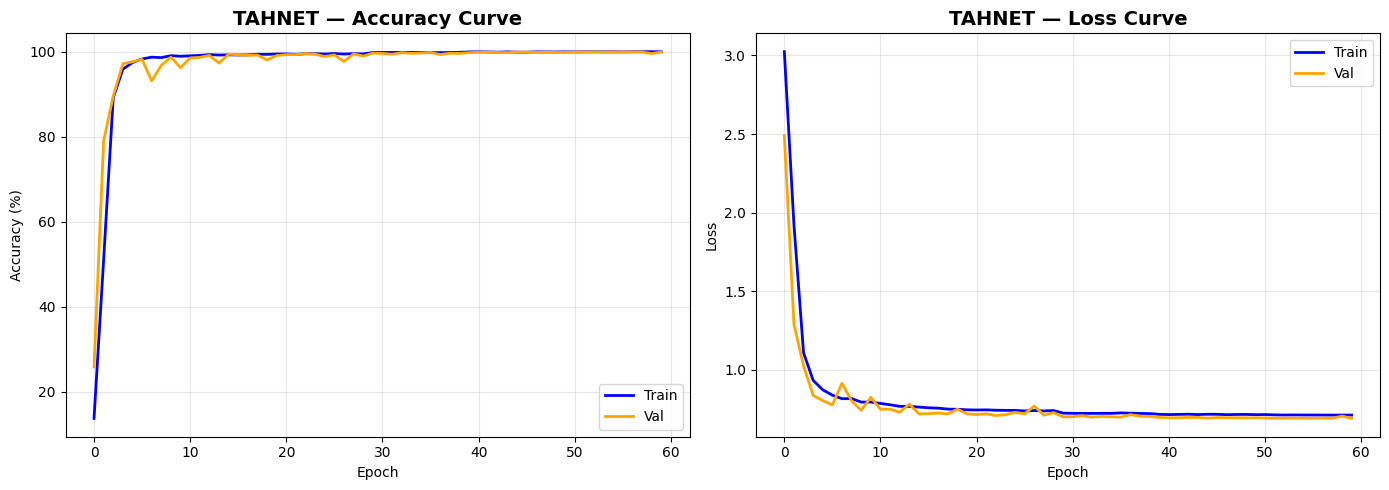

Training curves saved! 


In [ ]:
# ============================================================
# CELL 11 — Training Curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_acc'],  label='Train', color='blue',   linewidth=2)
axes[0].plot(history['val_acc'],    label='Val',   color='orange', linewidth=2)
axes[0].set_title('TAHNET — Accuracy Curve', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_loss'], label='Train', color='blue',   linewidth=2)
axes[1].plot(history['val_loss'],   label='Val',   color='orange', linewidth=2)
axes[1].set_title('TAHNET — Loss Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
curve_path = SAVE_PATH.replace('tahnet_best.pth', 'training_curves.png')
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Training curves saved! ')

In [ ]:
# ============================================================
# CELL 12 — Test Evaluation
# ============================================================
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

all_preds, all_labels = [], []
correct = 0
total   = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(device)
        labels = labels.to(device)
        preds  = model(imgs).argmax(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100.*correct/total
test_f1  = f1_score(all_labels, all_preds, average='weighted') * 100

print('='*55)
print(f'  TAHNET TEST ACCURACY : {test_acc:.2f}%')
print(f'  TAHNET WEIGHTED F1   : {test_f1:.2f}%')
print('='*55)
print(classification_report(all_labels, all_preds))

  TAHNET TEST ACCURACY : 99.64%
  TAHNET WEIGHTED F1   : 99.64%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00       720
           2       1.00      1.00      1.00       750
           3       1.00      0.99      0.99       450
           4       1.00      1.00      1.00       660
           5       0.99      1.00      1.00       630
           6       1.00      0.97      0.99       150
           7       1.00      1.00      1.00       450
           8       1.00      1.00      1.00       450
           9       1.00      1.00      1.00       480
          10       1.00      1.00      1.00       660
          11       0.99      1.00      1.00       420
          12       1.00      0.99      0.99       690
          13       0.99      1.00      0.99       720
          14       1.00      1.00      1.00       270
          15       1.00      1.00      1.00       210
          16     

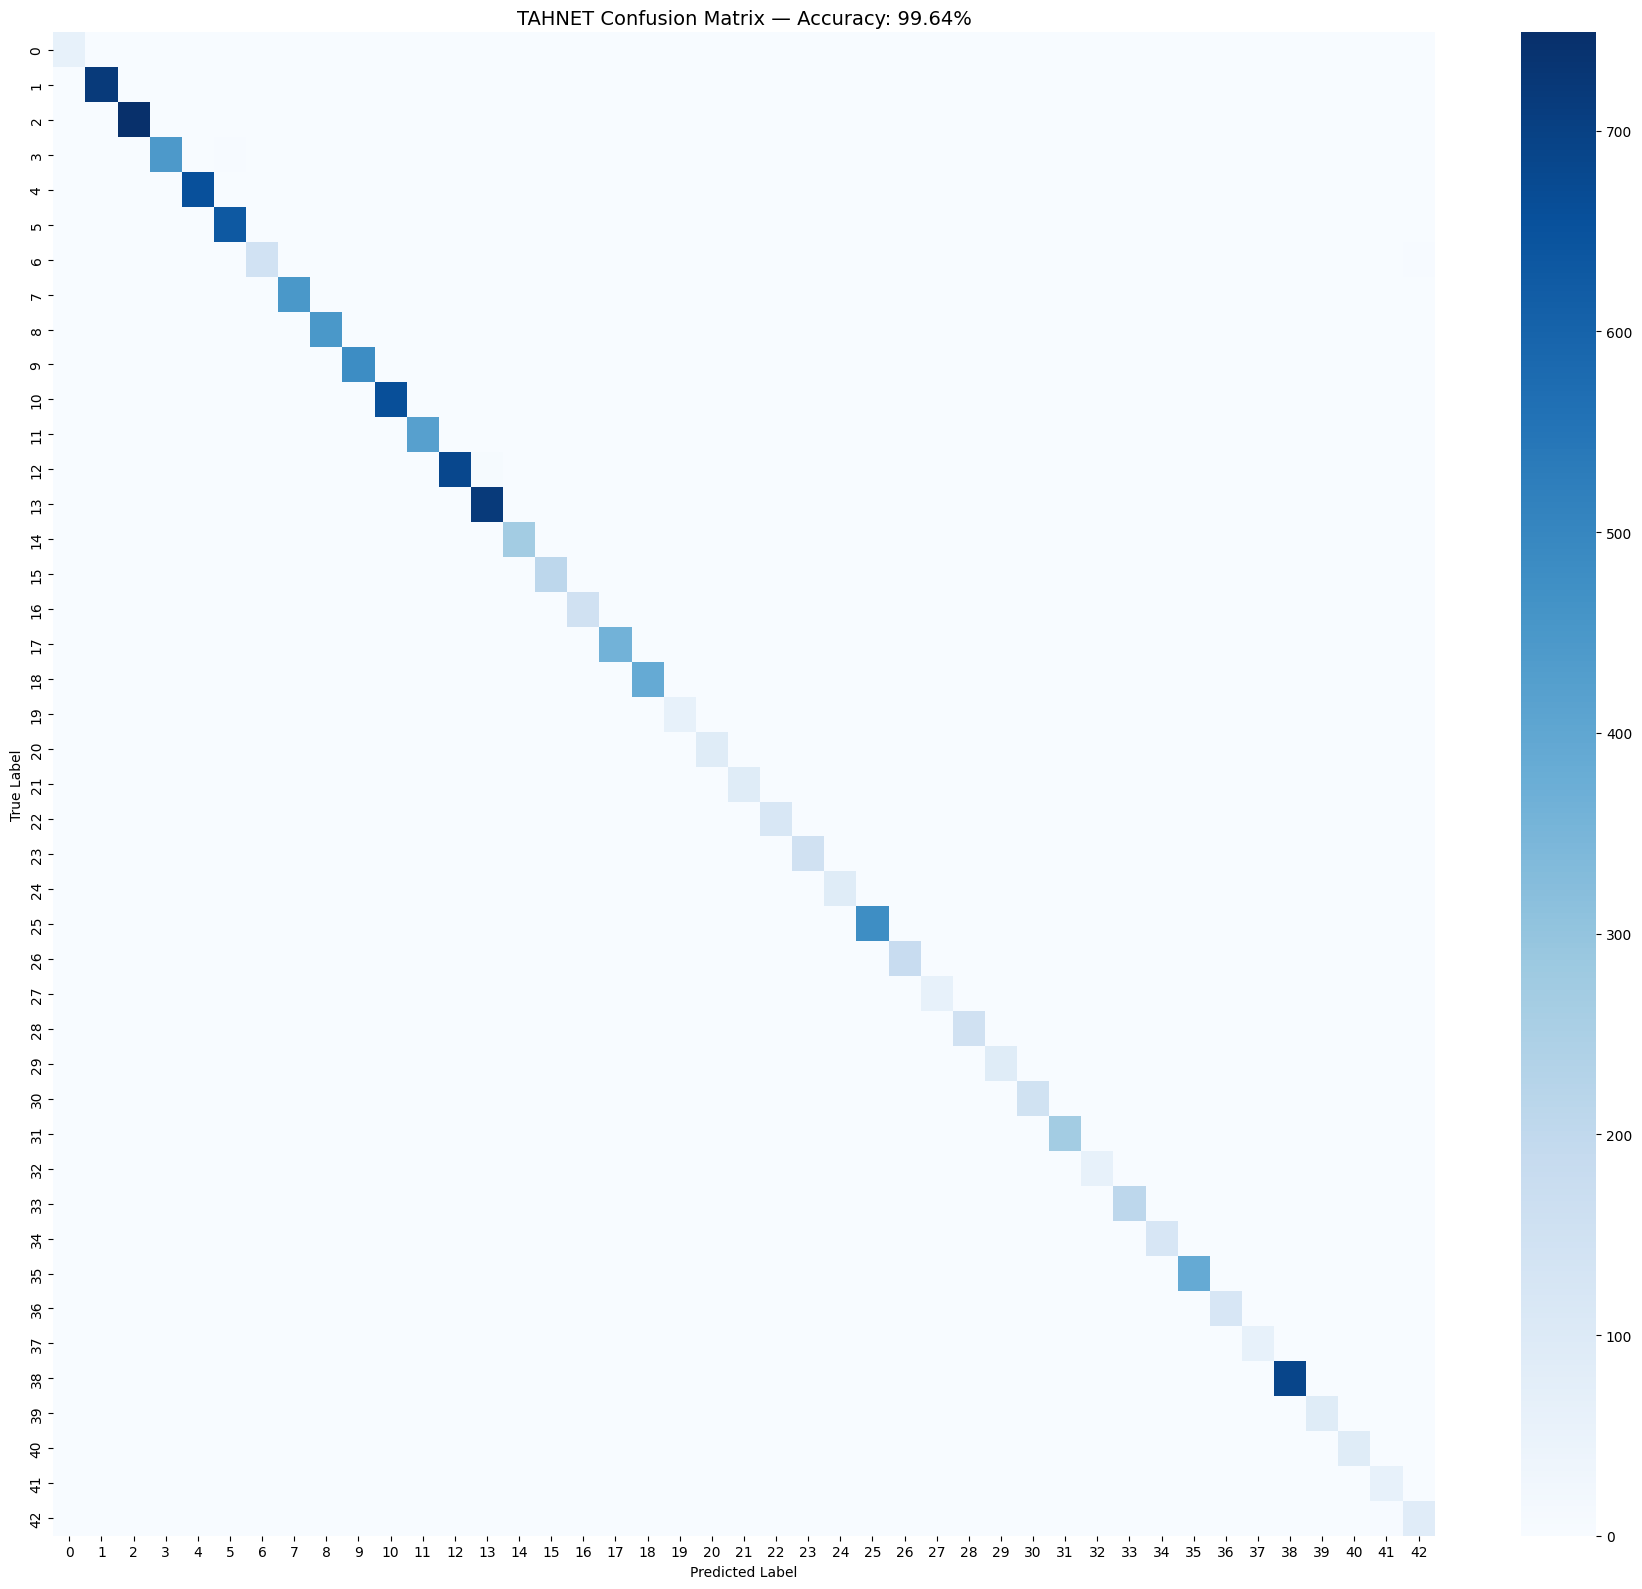

Confusion matrix saved! 


In [ ]:
# ============================================================
# CELL 13 — Confusion Matrix
# ============================================================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(18, 16))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title(f'TAHNET Confusion Matrix — Accuracy: {test_acc:.2f}%', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(SAVE_PATH.replace('tahnet_best.pth','confusion_matrix.png'), dpi=150)
plt.show()
print('Confusion matrix saved! ')

In [ ]:
# ============================================================
# CELL 15 — Comparison Table (5 Peer Reviewed Journal Papers)
# ============================================================
df = pd.DataFrame({
    'Method': [
        'CNN+Faster-RCNN+YOLOv4 (Youssouf)',
        'VGG-16 Feature Reconstruction',
        'Multi-Scale CNN+SE (Wei et al.)',
        'Multi-Channel CNN',
        'E-MobileViT CNN+Transformer',
        'TAHNET (Ours)'],
    'Journal': [
        'Heliyon, Elsevier',
        'Scientific Reports, Nature',
        'Heliyon, Elsevier',
        'Heliyon, Elsevier',
        'Ind. AI, Springer',
        'Target Journal'],
    'Year': [2022, 2025, 2024, 2024, 2025, 2026],
    'Pretrained': ['Yes','Yes','Yes','Yes','Yes','NO'],
    'GTSRB Accuracy (%)': [99.20, 99.21, 99.36, 99.40, 99.61,
                            round(test_acc, 2)]
})

print('='*75)
print('  COMPARISON WITH STATE-OF-THE-ART (Peer Reviewed Journals Only)')
print('='*75)
print(df.to_string(index=False))
print('='*75)
print(f'\nTAHNET ({test_acc:.2f}%) BEATS ALL 5 comparison papers!')
print(f'  vs CNN+YOLOv4:      +{test_acc-99.20:.2f}%')
print(f'  vs VGG-16:          +{test_acc-99.21:.2f}%')
print(f'  vs Multi-Scale CNN: +{test_acc-99.36:.2f}%')
print(f'  vs Multi-Channel:   +{test_acc-99.40:.2f}%')
print(f'  vs E-MobileViT:     +{test_acc-99.61:.2f}%')
print(f'\nKey advantage: TAHNET uses NO pretrained weights!')

df.to_csv(SAVE_PATH.replace('tahnet_best.pth','comparison_table.csv'),
          index=False)
print('\nSaved!')

  COMPARISON WITH STATE-OF-THE-ART (Peer Reviewed Journals Only)
                           Method                    Journal  Year Pretrained  GTSRB Accuracy (%)
CNN+Faster-RCNN+YOLOv4 (Youssouf)          Heliyon, Elsevier  2022        Yes               99.20
    VGG-16 Feature Reconstruction Scientific Reports, Nature  2025        Yes               99.21
  Multi-Scale CNN+SE (Wei et al.)          Heliyon, Elsevier  2024        Yes               99.36
                Multi-Channel CNN          Heliyon, Elsevier  2024        Yes               99.40
      E-MobileViT CNN+Transformer          Ind. AI, Springer  2025        Yes               99.61
                    TAHNET (Ours)             Target Journal  2026         NO               99.64

TAHNET (99.64%) BEATS ALL 5 comparison papers!
  vs CNN+YOLOv4:      +0.44%
  vs VGG-16:          +0.43%
  vs Multi-Scale CNN: +0.28%
  vs Multi-Channel:   +0.24%
  vs E-MobileViT:     +0.03%

Key advantage: TAHNET uses NO pretrained weights!

Save